In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
from matplotlib import patches
import networkx as nx 
import math
import numpy as np
import statistics
import tensorflow as tf
# read the csv file using read_csv function of pandas
from mpl_toolkits.mplot3d import Axes3D


def normalize_array(arr):
    min_value = min(arr)
    max_value = max(arr)
    normalized_arr = [(x - min_value)  / (max_value - min_value) for x in arr]
    return normalized_arr





test_image = "108.JPG"
filepath = "E:/SprayCraft/annotated_apple_leaf_disease/train/"

C:\Users\kethi\AppData\Local\Temp\ipykernel_18840\3022365737.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:

def generate_drone_boustrophedon_path(x_min, y_min,width, height, coverage_radius,path, z):
 
    curr_path = []
    full_coverage = coverage_radius*2
    partial = round(  ((height%full_coverage)/full_coverage)*coverage_radius, 1)
    y_start = y_min +( coverage_radius if (height%full_coverage) == 0 else partial)
    y_end = y_min + height 
    #y_end = height - coverage_radius
    x_end = x_min + width
    x_start = x_min+coverage_radius
    x = x_start 
    y = y_start

    #print("Full coverage: ",full_coverage)
        
    #print("X min : ", x_min, " X start: ", x , "Width is :",width, "X end: " , x_end, "X max: ",x_min+width )

    #print("Y min : ", y_min, " Y start: ", y_start , "Height is :",height, "Y end: " , y_end, "Y max: ",y_min+height )
    
    if(width > full_coverage  and height > full_coverage):
        while y <= y_end:
            if x == x_min + coverage_radius:
                # Move to the right
                while x <= x_end - coverage_radius :
                    curr_path.append((x, y, z))
                    x = round (x + 0.1 , 1)
                #print("X flipped, X: ", x)
                x = round (x - 0.1 , 1)
            else:
                # Move to the left
                while x >= x_min + coverage_radius:
                    curr_path.append((x, y, z))
                    x = round (x - 0.1 , 1)
                #print("X flipped, X: ", x)
                x = round (x + 0.1 , 1)
            y = round( y + full_coverage, 1)
            
            #print("adding full coverage and y is : ",y )

    if(width < full_coverage  and height > full_coverage):
        while y <= y_end:
            x = x_min + (width/2)
            curr_path.append((x, y, z))
            y = round( y + full_coverage, 1)

    if(width > full_coverage  and height < full_coverage):
        while x <= x_end - coverage_radius :
            y = y_min + (height/2)
            curr_path.append((x, y, z))
            x += 0.1

    if(width < full_coverage  and height < full_coverage):
       x = x_min + (width/2)
       y = y_min + (height/2)
       curr_path.append((x, y, z))
       x += 0.1   
       curr_path.append((x, y, z))

    x_start , y_start, z_start  = curr_path[0]
    x_end , y_end, z_end = curr_path[-1]
    x_curr, y_curr, z_curr = path[-1]

    dist_start = math.sqrt((x_start - x_curr) ** 2 + (y_start - y_curr) ** 2 )

    dist_end = math.sqrt((x_end - x_curr) ** 2 + (y_end - y_curr) ** 2 )

    if dist_start < dist_end:
        for coord in curr_path:
            path.append(coord)
            
    else:
        for coord in curr_path[::-1]:
            path.append(coord)
            
    
    return path

def plot_drone_boustrophedon_path(path, x_min, y_min, width, height, coverage_radius, conv):
    
    x, y, z = zip(*path)

    # Create figure and plot
    plt.figure(figsize=(15, 15))

    

    # Set axis limits and aspect ratio
    plt.xlim(x_min, x_min + width)
    plt.ylim(y_min, y_min + height)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca().set_ylim(bottom=250, top=0)  # Adjust y-axis limits if needed

    # Add labels and title
    plt.title('Boustrophedon Path for Spraying Drone')
    plt.xlabel('X (meters)')
    plt.ylabel('Y (meters)')
    plt.grid(True)


    # Load and display the background image
    image = plt.imread("BackGround.JPG")
    ax = plt.gca()
    ax.imshow(image, extent=(x_min, x_min + width, y_min, y_min + height))
    spc = 1
    for _,row in train[train.filename == picname].iterrows():
        xmin = row.xmin
        xmax = row.xmax
        ymin = row.ymin
        ymax = row.ymax
    
        width = xmax - xmin
        height = ymax - ymin
    
        
    # add bounding boxes to the image
        rect = patches.Rectangle((xmin,ymin), width, height, linewidth=0, edgecolor='red', facecolor='red', alpha=conv[spc - 1][0])
        box = patches.Rectangle((xmin,ymin), width, height, linewidth=1, edgecolor='black',facecolor='none')
        plt.gca().add_patch(rect)
        plt.gca().add_patch(box)
        spc += 1
        # Plot the drone path as arrows
    plt.quiver(x[:-1], y[:-1], np.diff(x), np.diff(y), scale_units='xy', angles='xy', scale=1, color='blue', label="Drone Path")
            
    plt.legend()

    plt.show()


In [3]:
def plot_drone_boustrophedon_path_3d(path):
  x, y, z = zip(*path)

# Create the figure and a 3D axis

  fig = plt.figure(figsize=(16, 16))
  ax = fig.add_subplot(111, projection='3d')

# Plot the points
  ax.plot(x, y, z,  label='Path')


# Set labels
  ax.set_xlabel('X')
  ax.set_ylabel('Y')      
  ax.set_zlabel('Z')
  ax.set_zlim(0, 5)
  ax.invert_yaxis()
  ax.legend()
  ax.view_init(elev=0, azim=180)
# Enable interactive rotation
  plt.show()

In [4]:
"""Stimator train"""



train = pd.read_csv(filepath + "train.csv")
#train.head()
labels = pd.read_csv(filepath + "labels.csv")
graphs = []
convolutions = []
for index, value in labels['image'].items():
    picname = str(value)+".JPG"
    currlabel = labels.loc[index, "label"]
    #print("pic: " + picname +", label: "+ str(currlabel))
    G = nx.Graph()
    nodeC = 0;
    #fig = plt.figure()

    #add axes to the image
    #ax = fig.add_axes([0,0,1,1])

    # read and plot the image
    #image = plt.imread('C:/Users/kethi/Documents/annotated_apple_leaf_disease/train/images/'+ picname)


    # iterating over the image for different objects
    
    spc = 1
    for _,row in train[train.filename == picname].iterrows():
        xmin = row.xmin
        xmax = row.xmax
        ymin = row.ymin
        ymax = row.ymax
    
        width = xmax - xmin
        height = ymax - ymin
    
        xpos = (xmax + xmin)/2
        ypos = (ymax + ymin)/2
        area = width * height 
        nodeC += 1
        G.add_nodes_from([(nodeC, {"area": area , "x" : xpos , "y" : ypos})])
    
    for u in G.nodes():
        for v in G.nodes():
            if u != v:
                dist = math.sqrt((G.nodes[u]['x'] - G.nodes[v]['x']) ** 2 + (G.nodes[u]['y'] - G.nodes[v]['y']) ** 2)
                if(dist < 60):
                    G.add_edge(u, v, weight=  (dist/60))
            else:
                 G.add_edge(u, v, weight=1)
   
    G.label = currlabel
    graphs.append(G)
    #nx.draw(G, with_labels=True)
    
    adj_matrix = nx.adjacency_matrix(G)
    # Convert the sparse matrix to a dense matrix
    adj_matrix_dense = adj_matrix.todense()

    # Convert the dense matrix to a NumPy array
    adj_matrix_array = np.array(adj_matrix_dense)
    degree_matrix = np.diag(np.sum(adj_matrix_array, axis=1))

    num_rows, num_cols = adj_matrix_array.shape
    num_nodes = G.number_of_nodes()

    #print("Number of nodes: ", num_nodes)
    #print("Number of rows: ", num_rows)
    #print("Number of columns: ", num_cols)

    features = np.array([G.nodes[i]["area"] for i in G.nodes()])
    features = features.reshape(len(features),1)
    # Convert the NumPy array to a dense matrix

    #print("Adjacency Matrix: ")
    #print(adj_matrix_array)
    #print("Node features: ")
    #print(features)

    conv =  np.dot(adj_matrix_array ,features )
    #conv = normalize_array(conv);
    #print("After message passing")
    #print(conv) 

    flat_conc = conv.flatten()
    padded_conv = np.pad(flat_conc, (0, 40 - len(flat_conc)), mode='constant')
    sort_conv = np.sort(padded_conv, kind='quicksort')[::-1]
    #print("Padded array: ")
    #print(padded_conv)
    convolutions.append(sort_conv)
    
print("Number of graphs generated: " + str(len(graphs)))
print("Number of convolved outputs: " + str(len(convolutions)))



Number of graphs generated: 400
Number of convolved outputs: 400


In [5]:
"""
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import ModelCheckpoint, History
#using convolutions as training data 
X_train = np.array(convolutions)

#building y train, the labels
y_train = np.column_stack((labels['label'],))


# Define the neural network model
model = Sequential()
model.add(Dense(40, input_shape=(40,), activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(5, activation='relu'))
model.add(Dense(1, activation='relu'))
# Compile the model with a loss function and optimizer
model.compile(loss='mean_squared_error', optimizer='adam')


print(model.summary())
# Train the model on your data
model.fit(X_train, y_train, epochs=1000, batch_size=100, verbose=1)

model.save('SprayCraft.h5')

"""

"\nfrom keras.models import Sequential\nfrom keras.layers import Dense\nfrom keras.callbacks import ModelCheckpoint, History\n#using convolutions as training data \nX_train = np.array(convolutions)\n\n#building y train, the labels\ny_train = np.column_stack((labels['label'],))\n\n\n# Define the neural network model\nmodel = Sequential()\nmodel.add(Dense(40, input_shape=(40,), activation='relu'))\nmodel.add(Dense(20, activation='relu'))\nmodel.add(Dense(10, activation='relu'))\nmodel.add(Dense(5, activation='relu'))\nmodel.add(Dense(1, activation='relu'))\n# Compile the model with a loss function and optimizer\nmodel.compile(loss='mean_squared_error', optimizer='adam')\n\n\nprint(model.summary())\n# Train the model on your data\nmodel.fit(X_train, y_train, epochs=1000, batch_size=100, verbose=1)\n\nmodel.save('SprayCraft.h5')\n\n"

Number of nodes:  36
Size of adjacency matrix:  (36, 36)
Node features befor message passing: 
[572  56  72 288  63  66  56 264 323  55  66 640 238 304 105 110 132 462
  20 270 110  96  81  64  72  90 180 182  21  78  42  64  72 165  77 154]
Adjacency Matrix: 
[[1.         0.         0.78266816 ... 0.         0.         0.        ]
 [0.         1.         0.78969052 ... 0.         0.         0.        ]
 [0.78266816 0.78969052 1.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 1.         0.186339   0.2422407 ]
 [0.         0.         0.         ... 0.186339   1.         0.42793107]
 [0.         0.         0.         ... 0.2422407  0.42793107 1.        ]]
Node features after message passing
[[1253.26804097  364.85579985 1234.43523463 2047.67910733  887.86007242
   887.00854593 1731.77122599 2168.82223242 1390.22899702 2322.65625994
  1015.51274091 2103.44970787 1157.0818617  2134.76750797 1712.52611886
  1093.52495067 1402.99539704 1375.07780277

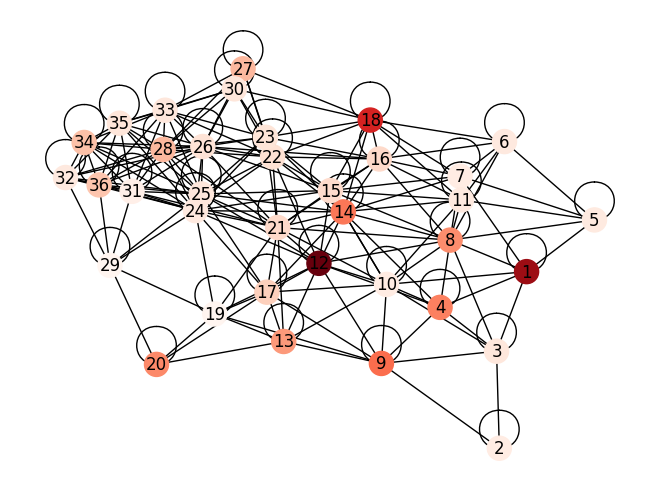

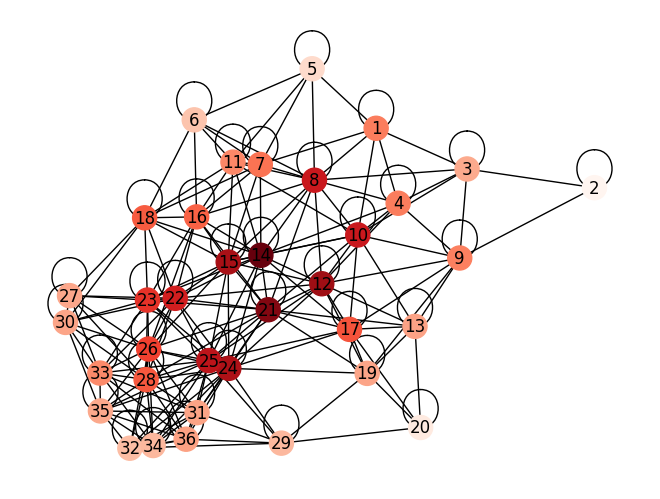

1/1 [==============================] - 2s 2s/step
Predicted percentage of area the disease has spread to:  74.48806
Computed percentage of area damaged by disease:  30.453333333333333
Computed severity measure:  43.23193448187667


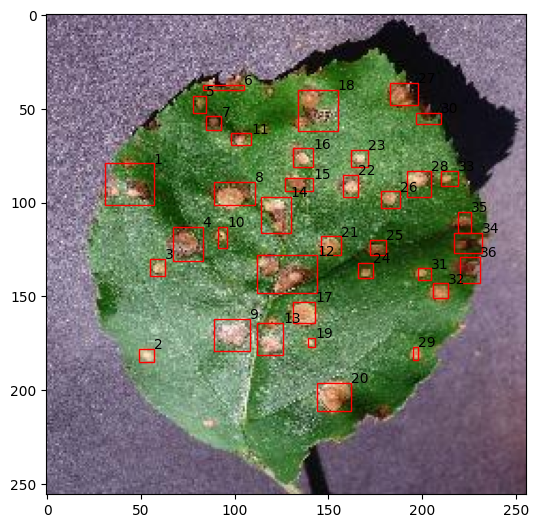

In [6]:
"""Stimator Test"""
model = tf.keras.models.load_model('SprayCraft.h5')

picname = test_image

#print("pic: " + picname +", label: "+ str(currlabel))
G = nx.Graph()
nodeC = 0;
#fig = plt.figure()

#add axes to the image
#ax = fig.add_axes([0,0,1,1])

# read and plot the image
#image = plt.imread('C:/Users/kethi/Documents/annotated_apple_leaf_disease/train/images/'+ picname)


# iterating over the image for different objects
    
spc = 1
for _,row in train[train.filename == picname].iterrows():
    xmin = row.xmin
    xmax = row.xmax
    ymin = row.ymin
    ymax = row.ymax
    
    width = xmax - xmin
    height = ymax - ymin
    
    xpos = (xmax + xmin)/2
    ypos = (ymax + ymin)/2
    area = width * height 
    nodeC += 1
    G.add_nodes_from([(nodeC, {"area": area , "x" : xpos , "y" : ypos})])
    
   
    for u in G.nodes():
        for v in G.nodes():
            if u != v:
                dist = math.sqrt((G.nodes[u]['x'] - G.nodes[v]['x']) ** 2 + (G.nodes[u]['y'] - G.nodes[v]['y']) ** 2)
                if(dist < 60):
                    G.add_edge(u, v , weight= (dist/60) )
            else:
                 G.add_edge(u, v)

                    
                    
adj_matrix = nx.adjacency_matrix(G)
# Convert the sparse matrix to a dense matrix
adj_matrix_dense = adj_matrix.todense()

# Convert the dense matrix to a NumPy array
adj_matrix_array = np.array(adj_matrix_dense)


num_rows, num_cols = adj_matrix_array.shape
num_nodes = G.number_of_nodes()

print("Number of nodes: ", num_nodes)
print("Size of adjacency matrix: ", adj_matrix_array.shape)
#print("Number of rows: ", num_rows)
#print("Number of columns: ", num_cols)

features = np.array([G.nodes[i]["area"] for i in G.nodes()])
print("Node features befor message passing: ")
tempF = np.array(features)
tempF = normalize_array(tempF);
print(np.array(features))
features = features.reshape(len(features),1)
# Convert the NumPy array to a dense matrix

print("Adjacency Matrix: ")
print(adj_matrix_array)
#print("Node features: ")
#print(features)

conv =  np.dot(adj_matrix_array ,features )
#conv = conv2
conv2 =  np.dot(adj_matrix_array ,conv )    
conv2UNN = conv2

 
#conv2 = normalize_array(conv2);

print("Node features after message passing")
print(np.array(conv).reshape(1, -1) )

flat_conc = np.array(conv).flatten()
padded_conv = np.pad(flat_conc, (0, 40 - len(flat_conc)), mode='constant')
sort_conv = np.sort(padded_conv, kind='quicksort')[::-1]
    
    
node_areas = [G.nodes[n]['area'] for n in G.nodes()]
areasum = sum(node_areas)*100 / (125*150)

nx.draw(G, node_color=node_areas, cmap='Reds', with_labels=True)

plt.show()

nx.draw(G, node_color=conv2, cmap='Reds', with_labels=True)

plt.show()

X_test = []
X_test.append(sort_conv)
predictions = model.predict(np.array(X_test))
if predictions[0][0] > 100:
    predictions[0][0] = 100
print("Predicted percentage of area the disease has spread to: ",predictions[0][0])
print("Computed percentage of area damaged by disease: " ,areasum)
print("Computed severity measure: ", statistics.harmonic_mean([areasum, predictions[0][0]]) )
image = plt.imread(filepath+'images/'+ str(picname) )
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])    
spc = 1
for _,row in train[train.filename == picname].iterrows():
    xmin = row.xmin
    xmax = row.xmax
    ymin = row.ymin
    ymax = row.ymax
    
    width = xmax - xmin
    height = ymax - ymin
    
        
   
    
    if row.object_name == 'Black Rot':
        edgecolor = 'r'
        ax.annotate( str(spc), xy=(xmax,ymin))
    elif row.object_name == 'Cedar Apple Rust':
        edgecolor = 'b'
        ax.annotate( str(spc), xy=(xmax,ymin))
    elif row.object_name == 'Apple Scab':
        edgecolor = 'g'
        ax.annotate( str(spc), xy=(xmax,ymin))
        
    # add bounding boxes to the image
    #rect = patches.Rectangle((xmin,ymin), width, height, linewidth=0, edgecolor='red', facecolor='red', alpha=conv2[spc - 1][0])
    
    rect = patches.Rectangle((xmin,ymin), width, height, edgecolor = edgecolor, facecolor = 'none')
    plt.gca().add_patch(rect)
    spc += 1
    
    
plt.imshow(image) 

Number of nodes:  36
Size of adjacency matrix:  (36, 36)
Node features befor message passing: 
[572  56  72 288  63  66  56 264 323  55  66 640 238 304 105 110 132 462
  20 270 110  96  81  64  72  90 180 182  21  78  42  64  72 165  77 154]
Adjacency Matrix: 
[[1.         0.         0.32914158 ... 0.         0.         0.        ]
 [0.         1.         0.32312241 ... 0.         0.         0.        ]
 [0.32914158 0.32312241 1.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 1.         0.84028086 0.79236512]
 [0.         0.         0.         ... 0.84028086 1.         0.63320194]
 [0.         0.         0.         ... 0.79236512 0.63320194 1.        ]]
Normalized node features after message passing
[[0.17674014 0.         0.26731576 0.5024923  0.22716563 0.21703679
  0.4087305  0.7979084  0.43033487 0.75179961 0.59508422 0.91774317
  0.52001114 1.         0.98291124 0.84148347 0.69429327 0.48094025
  0.50870708 0.13172514 0.96272382 0.9086007

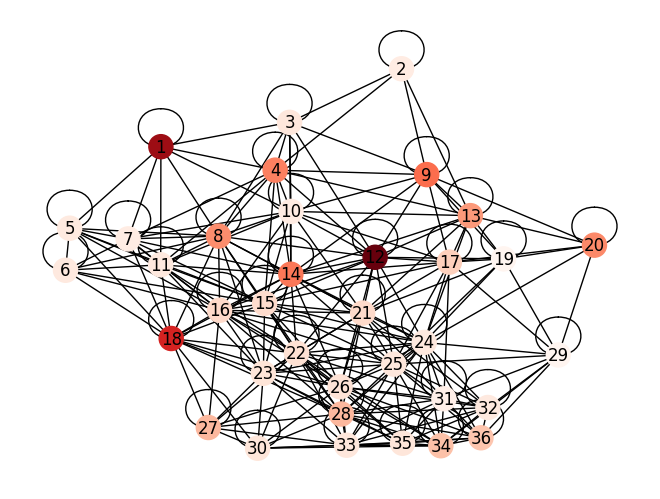

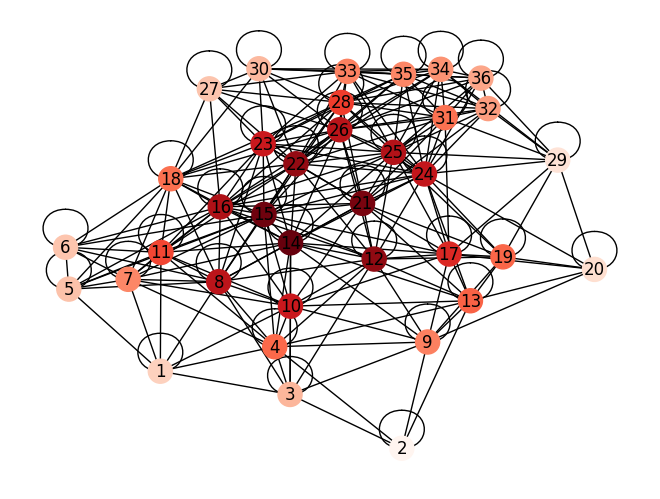

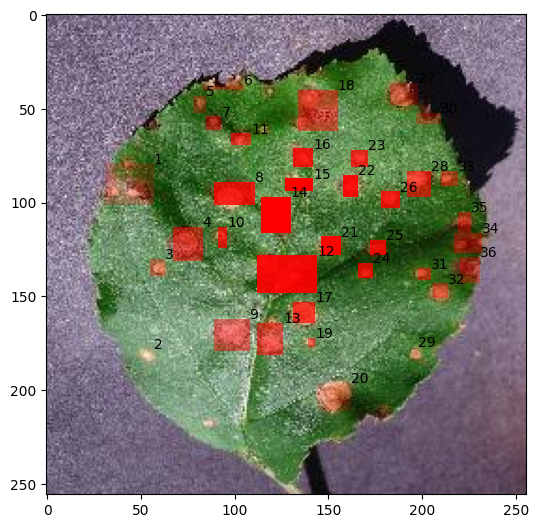

In [7]:
picname = test_image

#print("pic: " + picname +", label: "+ str(currlabel))
G = nx.Graph()
nodeC = 0;
#fig = plt.figure()

#add axes to the image
#ax = fig.add_axes([0,0,1,1])

# read and plot the image
#image = plt.imread('C:/Users/kethi/Documents/annotated_apple_leaf_disease/train/images/'+ picname)


# iterating over the image for different objects
    
spc = 1
for _,row in train[train.filename == picname].iterrows():
    xmin = row.xmin
    xmax = row.xmax
    ymin = row.ymin
    ymax = row.ymax
    
    width = xmax - xmin
    height = ymax - ymin
    
    xpos = (xmax + xmin)/2
    ypos = (ymax + ymin)/2
    area = width * height 
    nodeC += 1
    G.add_nodes_from([(nodeC, {"area": area , "x" : xpos , "y" : ypos})])
    
   
    for u in G.nodes():
        for v in G.nodes():
            if u != v:
                dist = math.sqrt((G.nodes[u]['x'] - G.nodes[v]['x']) ** 2 + (G.nodes[u]['y'] - G.nodes[v]['y']) ** 2)
                if(dist < 70):
                    G.add_edge(u, v , weight=  1 - (dist/70) )
            else:
                 G.add_edge(u, v)

                    
                    
adj_matrix = nx.adjacency_matrix(G)
# Convert the sparse matrix to a dense matrix
adj_matrix_dense = adj_matrix.todense()

# Convert the dense matrix to a NumPy array
adj_matrix_array = np.array(adj_matrix_dense)


num_rows, num_cols = adj_matrix_array.shape
num_nodes = G.number_of_nodes()

print("Number of nodes: ", num_nodes)
print("Size of adjacency matrix: ", adj_matrix_array.shape)
#print("Number of rows: ", num_rows)
#print("Number of columns: ", num_cols)

features = np.array([G.nodes[i]["area"] for i in G.nodes()])
print("Node features befor message passing: ")
print(np.array(features))
features = features.reshape(len(features),1)
# Convert the NumPy array to a dense matrix

print("Adjacency Matrix: ")
print(adj_matrix_array)
#print("Node features: ")
#print(features)

conv =  np.dot(adj_matrix_array ,features )
conv =  np.dot(adj_matrix_array ,conv ) 



 
conv = normalize_array(conv);

print("Normalized node features after message passing")
print(np.array(conv).reshape(1, -1) )

flat_conc = np.array(conv).flatten()
padded_conv = np.pad(flat_conc, (0, 40 - len(flat_conc)), mode='constant')
sort_conv = np.sort(padded_conv, kind='quicksort')[::-1]
    
    
node_areas = [G.nodes[n]['area'] for n in G.nodes()]
areasum = sum(node_areas)*100 / (125*150)

nx.draw(G, node_color=node_areas, cmap='Reds', with_labels=True)

plt.show()

nx.draw(G, node_color=conv, cmap='Reds', with_labels=True)

plt.show()



#print("Computed percentage of area damaged by disease: " ,areasum)

image = plt.imread(filepath+'images/'+ str(picname) )
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])    
spc = 1
for _,row in train[train.filename == picname].iterrows():
    xmin = row.xmin
    xmax = row.xmax
    ymin = row.ymin
    ymax = row.ymax
    
    width = xmax - xmin
    height = ymax - ymin
    
        
   
    
    if row.object_name == 'Black Rot':
        edgecolor = 'r'
        ax.annotate( str(spc), xy=(xmax,ymin))
    elif row.object_name == 'Cedar Apple Rust':
        edgecolor = 'b'
        ax.annotate( str(spc), xy=(xmax,ymin))
    elif row.object_name == 'Apple Scab':
        edgecolor = 'g'
        ax.annotate( str(spc), xy=(xmax,ymin))
        
    # add bounding boxes to the image
    rect = patches.Rectangle((xmin,ymin), width, height, linewidth=0, edgecolor='red', facecolor='red', alpha=conv[spc - 1][0])
    plt.gca().add_patch(rect)
    spc += 1
    
    
plt.imshow(image) 

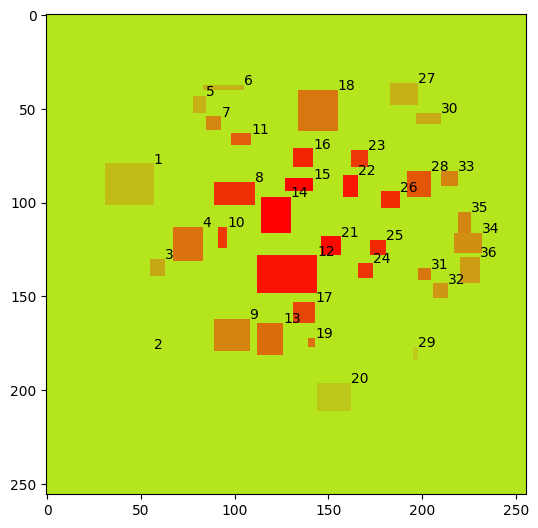

In [8]:
image = plt.imread("BackGround.JPG")
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])    
spc = 1
for _,row in train[train.filename == picname].iterrows():
    xmin = row.xmin
    xmax = row.xmax
    ymin = row.ymin
    ymax = row.ymax
    
    width = xmax - xmin
    height = ymax - ymin
    
        
   
    
    if row.object_name == 'Black Rot':
        edgecolor = 'r'
        ax.annotate( str(spc), xy=(xmax,ymin))
    elif row.object_name == 'Cedar Apple Rust':
        edgecolor = 'b'
        ax.annotate( str(spc), xy=(xmax,ymin))
    elif row.object_name == 'Apple Scab':
        edgecolor = 'g'
        ax.annotate( str(spc), xy=(xmax,ymin))
        
    # add bounding boxes to the image
    rect = patches.Rectangle((xmin,ymin), width, height, linewidth=0, edgecolor='red', facecolor='red', alpha=conv[spc - 1][0])
    plt.gca().add_patch(rect)
    spc += 1
    
    
plt.imshow(image) 

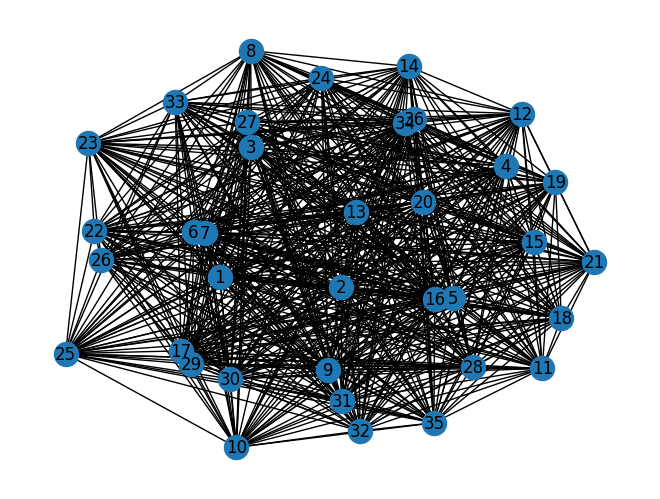

In [9]:
picname = test_image

#print("pic: " + picname +", label: "+ str(currlabel))
G = nx.Graph()
nodeC = 0;
#fig = plt.figure()

#add axes to the image
#ax = fig.add_axes([0,0,1,1])

# read and plot the image
#image = plt.imread('C:/Users/kethi/Documents/annotated_apple_leaf_disease/train/images/'+ picname)


# iterating over the image for different objects
instances_list =[]
spc = 1
for _,row in train[train.filename == picname].iterrows():

    
    
    xmin = row.xmin
    xmax = row.xmax
    ymin = row.ymin
    ymax = row.ymax
    
    width = xmax - xmin
    height = ymax - ymin

    instances_list.append([xmin ,ymin, width, height])
    
    xpos = (xmax + xmin)/2
    ypos = (ymax + ymin)/2
    area = width * height 
    nodeC += 1
    G.add_nodes_from([(nodeC, {"area": area , "x" : xpos , "y" : ypos})])
    
   
    for u in G.nodes():
        for v in G.nodes():
            if u != v:
                dist = math.sqrt((G.nodes[u]['x'] - G.nodes[v]['x']) ** 2 + (G.nodes[u]['y'] - G.nodes[v]['y']) ** 2)
                G.add_edge(u, v , weight= (dist) )
            

nx.draw(G, with_labels=True)









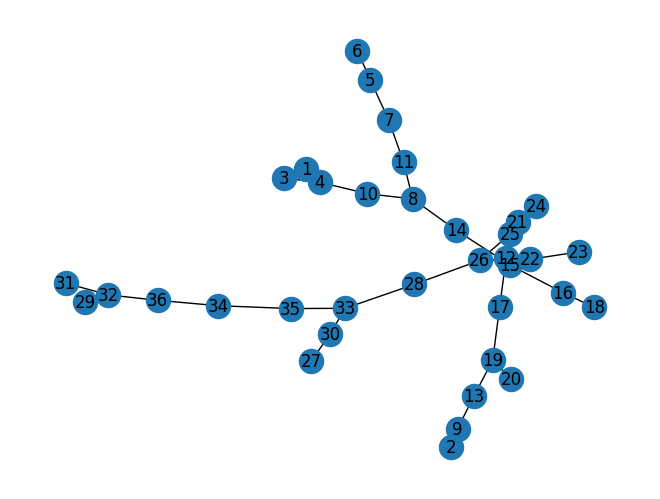

In [10]:
# Generate the Minimum Spanning Tree (MST)
MST = nx.minimum_spanning_tree(G, weight='weight')


nx.draw(MST, with_labels=True)

In [11]:
route = nx.approximation.christofides(G)
cost = sum(G[n][nbr]["weight"] for n, nbr in nx.utils.pairwise(route))

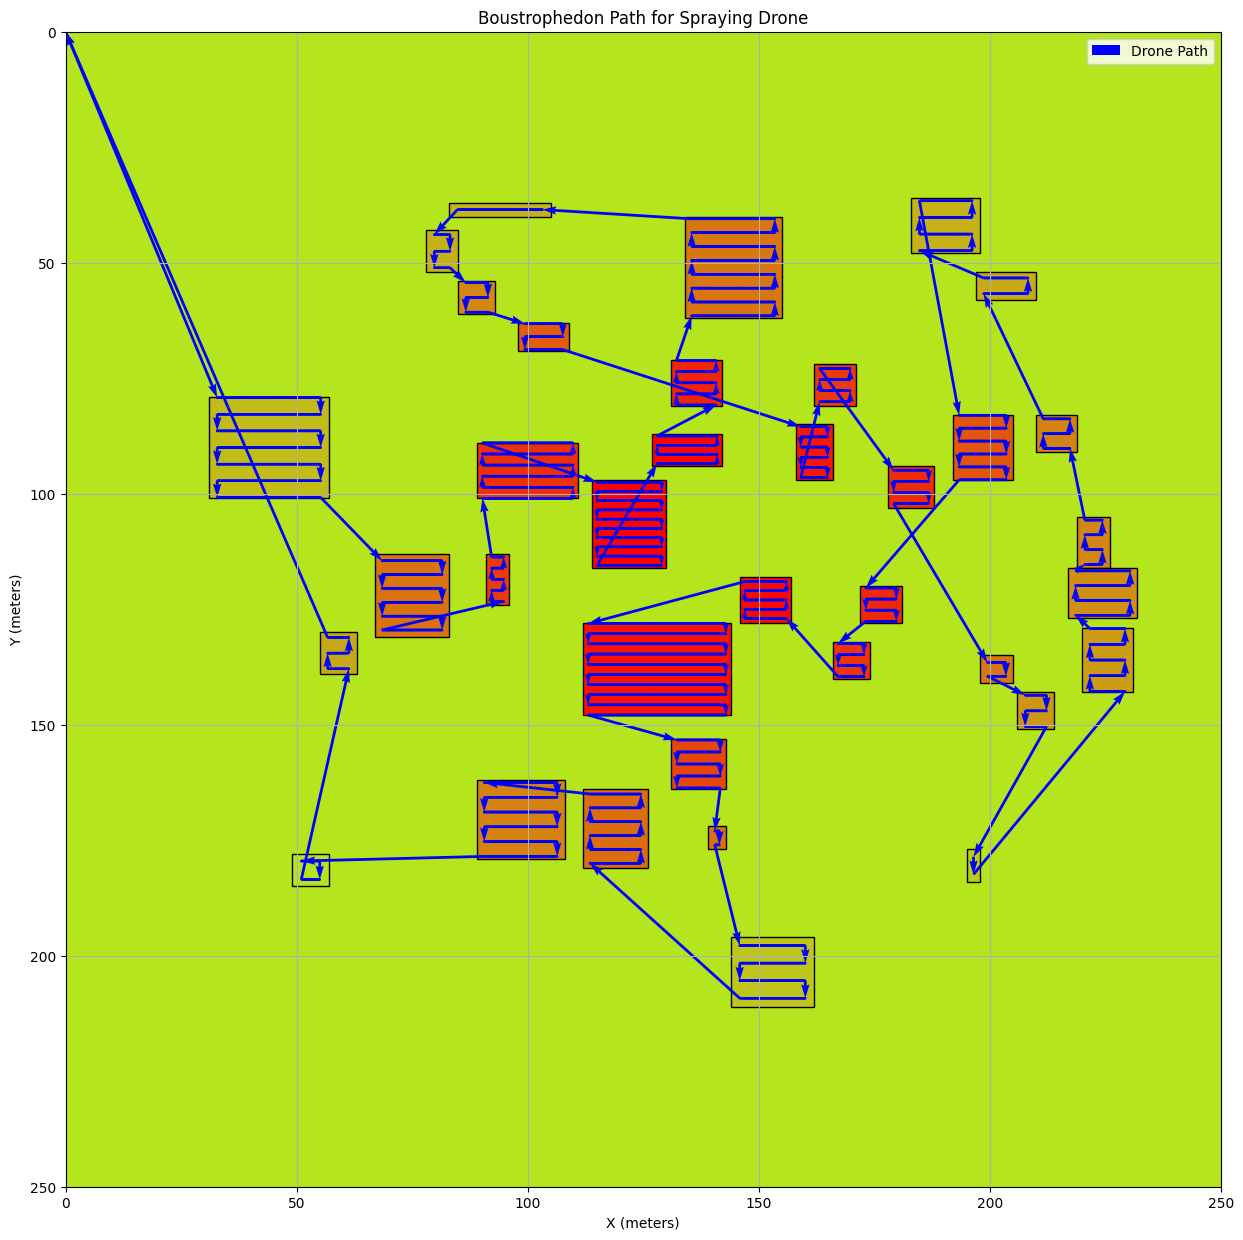

In [12]:
path = []
sno =1;
path.append((0, 0, 0))
for instance in route[:-1]:
    xmin ,ymin, width, height = instances_list[instance-1]
    coverage_radius = round( 2 - 1*conv[instance - 1][0], 1)
    #print("S NO :",sno ,"Nodr NO :",instance ," coverage radius :", coverage_radius)
    #print("X min is ", xmin , "Y min is ", ymin, "Width is ", width, "Height is ", height)
    path = generate_drone_boustrophedon_path(xmin ,ymin, width, height, coverage_radius,path, coverage_radius)
    #print("-------------------------------------------------------------------------------")
    sno += 1
path.append((0, 0, 0))   

plot_drone_boustrophedon_path(path, 0 ,0, 250, 250, coverage_radius,conv)



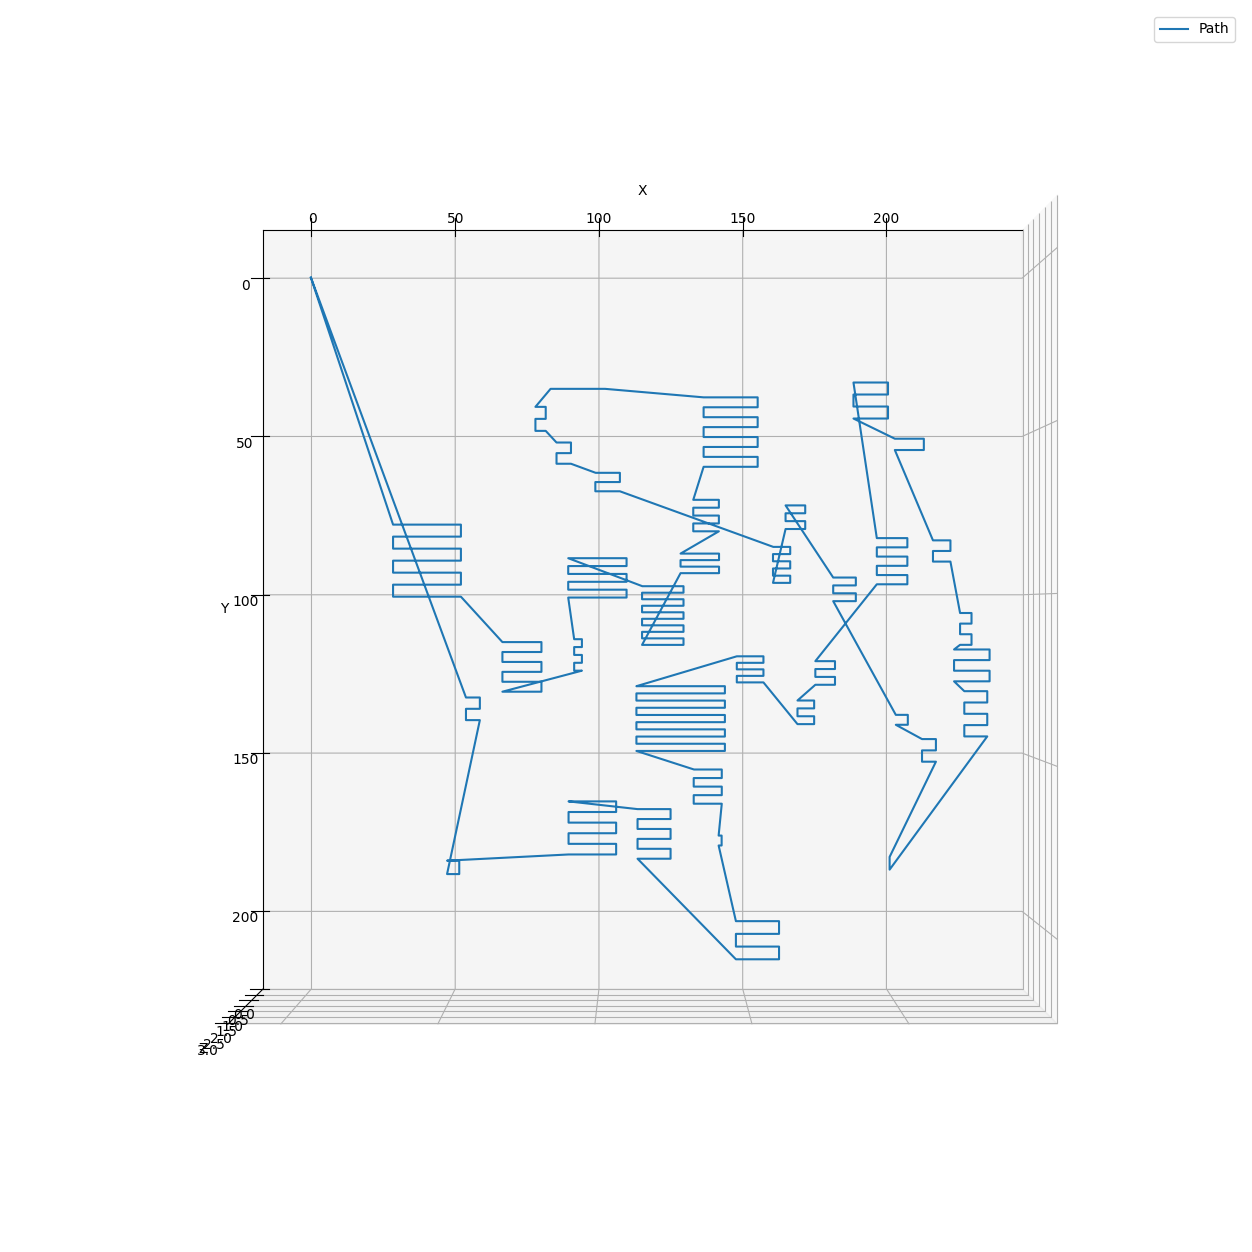

In [13]:
#plot_drone_boustrophedon_path_3d(path)
x, y, z = zip(*path)

# Create the figure and a 3D axis

fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.plot(x, y, z,  label='Path')


# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_zlim(0, 3)
ax.invert_yaxis()
ax.legend()
ax.view_init(elev=90, azim=270)
# Enable interactive rotation
plt.show()


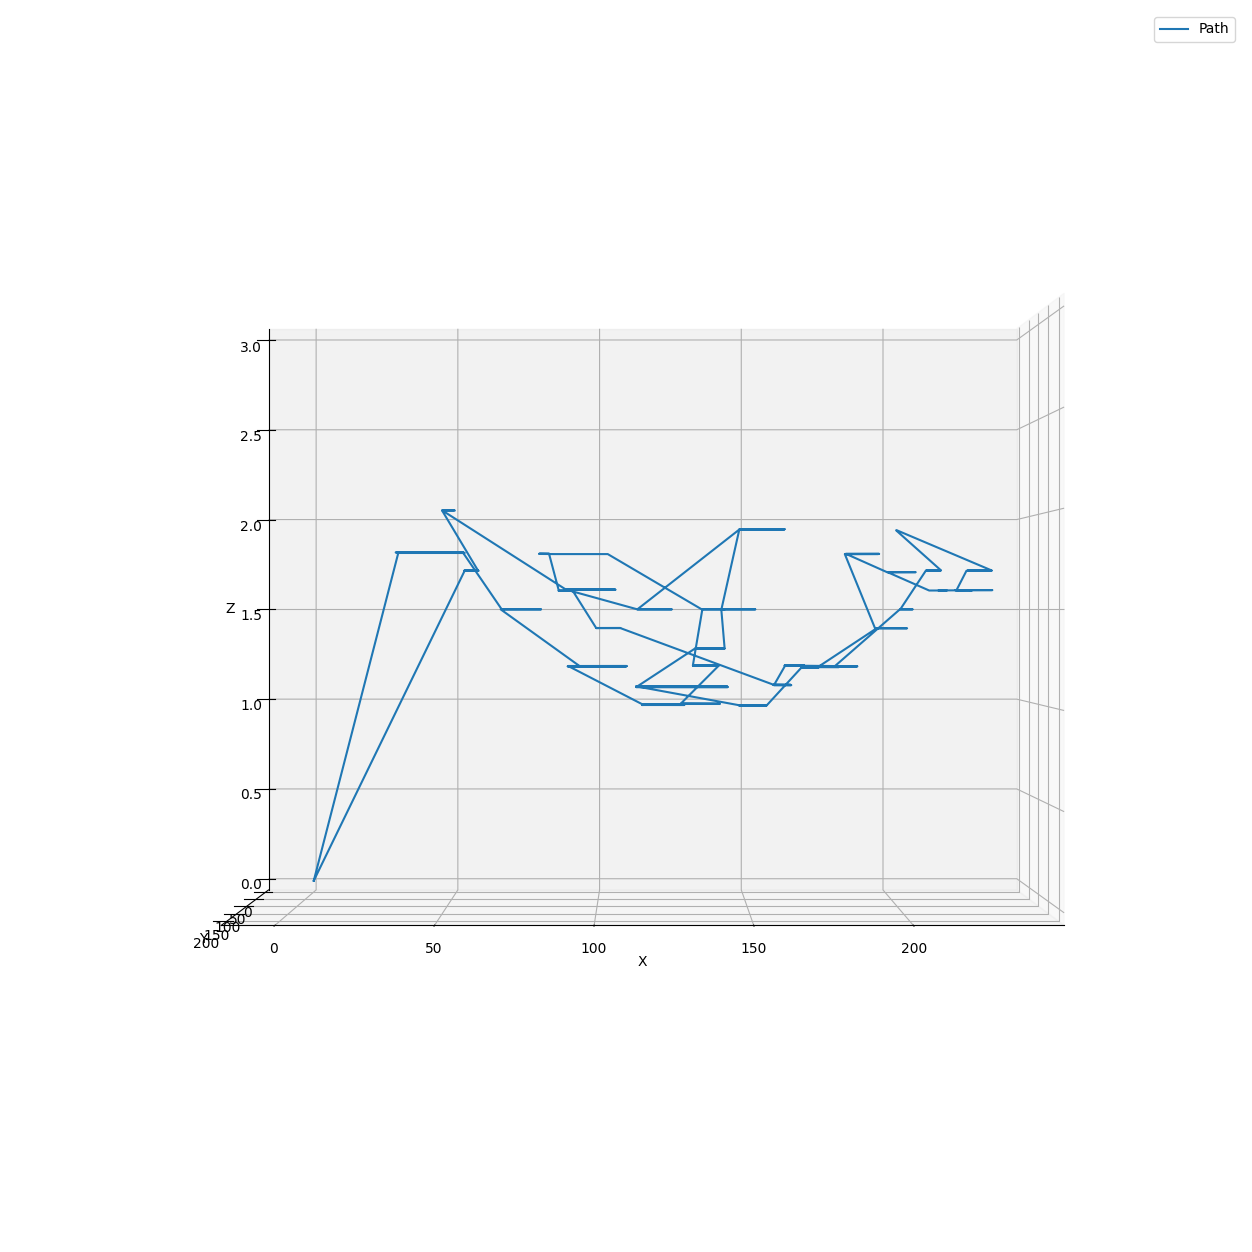

In [14]:
#plot_drone_boustrophedon_path_3d(path)
x, y, z = zip(*path)

# Create the figure and a 3D axis

fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.plot(x, y, z,  label='Path')


# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_zlim(0, 3)
ax.invert_yaxis()
ax.legend()
ax.view_init(elev=0, azim=270)
# Enable interactive rotation
plt.show()


In [17]:
total_distance = 0
points = np.array(path)
for i in range(1, len(points)):
    distance = np.linalg.norm(points[i] - points[i-1])
    total_distance += distance

print("Total distance covered:", total_distance)

Total distance covered: 3254.7063732281426
